### **K-Nearest Neighbors => Classification**

___

In [205]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [206]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings("ignore")

In [207]:
df = pd.read_csv("KNN_Project_Data")
df.head()   

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
0,1636.670614,817.988525,2565.995189,358.347163,550.417491,1618.870897,2147.641254,330.727893,1494.878631,845.136088,0
1,1013.402760,577.587332,2644.141273,280.428203,1161.873391,2084.107872,853.404981,447.157619,1193.032521,861.081809,1
2,1300.035501,820.518697,2025.854469,525.562292,922.206261,2552.355407,818.676686,845.491492,1968.367513,1647.186291,1
3,1059.347542,1066.866418,612.000041,480.827789,419.467495,685.666983,852.867810,341.664784,1154.391368,1450.935357,0
4,1018.340526,1313.679056,950.622661,724.742174,843.065903,1370.554164,905.469453,658.118202,539.459350,1899.850792,0


In [208]:
df.shape

(1000, 11)

In [209]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   XVPM          1000 non-null   float64
 1   GWYH          1000 non-null   float64
 2   TRAT          1000 non-null   float64
 3   TLLZ          1000 non-null   float64
 4   IGGA          1000 non-null   float64
 5   HYKR          1000 non-null   float64
 6   EDFS          1000 non-null   float64
 7   GUUB          1000 non-null   float64
 8   MGJM          1000 non-null   float64
 9   JHZC          1000 non-null   float64
 10  TARGET CLASS  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [210]:
df.describe()

,XVPM,GWYH,TRAT,TLLZ,IGGA,HYKR,EDFS,GUUB,MGJM,JHZC,TARGET CLASS
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,1055.071157,991.851567,1529.373525,495.107156,940.590072,1550.637455,1561.003252,561.346117,1089.067338,1452.521629,0.50000
std,370.980193,392.278890,640.286092,142.789188,345.923136,493.491988,598.608517,247.357552,402.666953,568.132005,0.50025
min,21.170000,21.720000,31.800000,8.450000,17.930000,27.930000,31.960000,13.520000,23.210000,30.890000,0.00000
25%,767.413366,694.859326,1062.600806,401.788135,700.763295,1219.267077,1132.097865,381.704293,801.849802,1059.499689,0.00000
50%,1045.904805,978.355081,1522.507269,500.197421,939.348662,1564.996551,1565.882879,540.420379,1099.087954,1441.554053,0.50000
75%,1326.065178,1275.528770,1991.128626,600.525709,1182.578166,1891.937040,1981.739411,725.762027,1369.923665,1864.405512,1.00000
max,2117.000000,2172.000000,3180.000000,845.000000,1793.000000,2793.000000,3196.000000,1352.000000,2321.000000,3089.000000,1.00000


In [211]:
df["TARGET CLASS"].value_counts()

TARGET CLASS
0    500
1    500
Name: count, dtype: int64

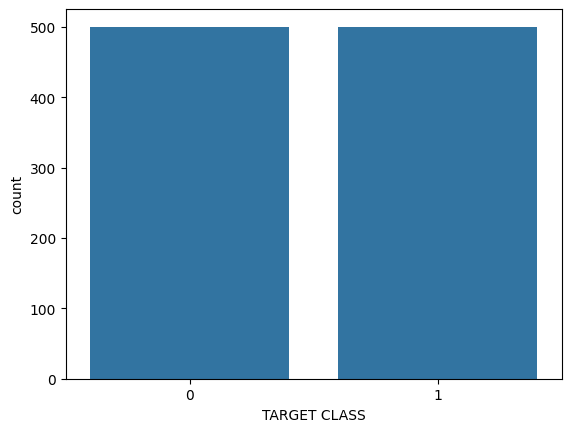

In [212]:
sns.countplot(x="TARGET CLASS", data=df)
plt.show()

In [213]:
df.isnull().sum()

XVPM            0
GWYH            0
TRAT            0
TLLZ            0
IGGA            0
HYKR            0
EDFS            0
GUUB            0
MGJM            0
JHZC            0
TARGET CLASS    0
dtype: int64

In [214]:
#scaling the data
x = df.drop("TARGET CLASS", axis=1)
y = df["TARGET CLASS"]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [215]:
x_train

array([[ 1.24420596,  0.12365499, -1.81034361, ..., -0.67257901,
        -0.79081682, -0.5849472 ],
       [ 1.46108652, -0.6800883 ,  0.51934786, ..., -1.46984471,
         0.71361945, -1.63313489],
       [ 1.24956253,  1.73728314, -0.41465578, ..., -0.76296048,
        -1.76665104, -0.16191105],
       ...,
       [ 1.56401636, -1.0614503 ,  0.85130431, ..., -1.32281943,
         0.66521304, -0.45065393],
       [ 1.18382721, -0.03580113, -0.21109051, ..., -1.22472333,
         1.01267261, -0.07491127],
       [ 0.72903512, -1.60631123,  1.2667385 , ..., -1.25327556,
         0.11486512, -0.79816418]], shape=(800, 10))

In [216]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 10)
(200, 10)
(800,)
(200,)


In [217]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3) 

In [218]:
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [219]:
y_pred = knn.predict(x_test)

In [220]:
print(f"confusion_matrix: \n{confusion_matrix(y_test, y_pred)}")

confusion_matrix: 
[[78 22]
 [18 82]]


In [221]:
print(f"classification_report: \n{classification_report(y_test, y_pred)}")

classification_report: 
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       100
           1       0.79      0.82      0.80       100

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



In [222]:
# Try Logistic Regression
from sklearn.linear_model import LogisticRegression
logmodel = LogisticRegression()
logmodel.fit(x_train, y_train)
y_pred_log = logmodel.predict(x_test)
print(f"Accuracy Score for Logistic Regression: \n{accuracy_score(y_test, y_pred_log)}")

Accuracy Score for Logistic Regression: 
0.865


In [223]:
#Try Decision Tree
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(max_depth=10)
dtree.fit(x_train, y_train)
y_pred_dtree = dtree.predict(x_test)
print(f"Accuracy Score for Decision Tree: \n{accuracy_score(y_test, y_pred_dtree)}")

Accuracy Score for Decision Tree: 
0.76


In [224]:
#Try Random Forest
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=600, max_depth=10, random_state=42, min_samples_split=5)
rfc.fit(x_train, y_train)
y_pred_rfc = rfc.predict(x_test)
print(f"Accuracy Score for Random Forest: \n{accuracy_score(y_test, y_pred_rfc)}")

Accuracy Score for Random Forest: 
0.845


#### **=> Try grid search to find the best K value for KNN**

In [225]:
from sklearn.model_selection import GridSearchCV
model = KNeighborsClassifier()
param_grid = {
    "n_neighbors": np.arange(1, 30),
    "p" : [1, 2] # p=1 for Manhattan distance, p=2 for Euclidean distance
   }

knn_gscv = GridSearchCV(model, param_grid)
knn_gscv.fit(x_train, y_train)

GridSearchCV(estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]),
                         'p': [1, 2]})

In [226]:
print(f"Best K value: {knn_gscv.best_params_}")
print(f"Best Score: {knn_gscv.best_score_}")

Best K value: {'n_neighbors': np.int64(22), 'p': 2}
Best Score: 0.8237500000000001


### **=> Comparing the models:**
___

In [227]:
# Comparing the models with a DataFrame
models = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression", "Decision Tree", "Random Forest", "GridSearchCV KNN"],
    "Score": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_dtree), accuracy_score(y_test, y_pred_rfc), knn_gscv.best_score_]
})

models.sort_values(by="Score", ascending=False)

,Model,Score
1,Logistic Regression,0.86500
3,Random Forest,0.84500
4,GridSearchCV KNN,0.82375
0,KNN,0.80000
2,Decision Tree,0.76000


In [228]:
# we that grid increases the accuracy of KNN model, but it is still not the best 
# so we will try looping through different K values to find the best one without using GridSearchCV

In [229]:
scores = []
for k in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(x_train, y_train)
    scores.append(knn.score(x_test, y_test))

In [230]:
max_score = max(scores)
best_k = scores.index(max_score) + 1
print(f"Best K value: {best_k}")
print(f"Best Score: {max_score}")

Best K value: 20
Best Score: 0.86


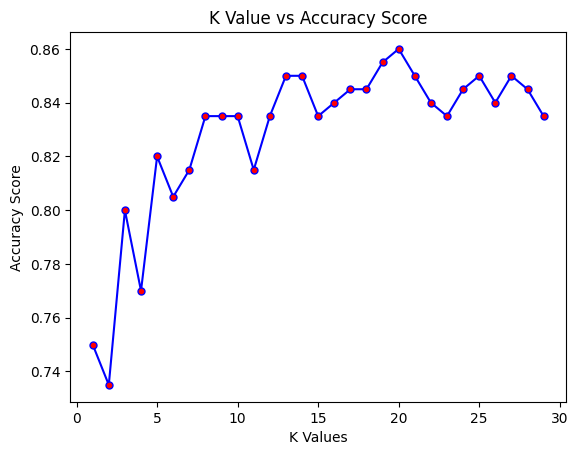

In [231]:
plt.plot(range(1, 30), scores, color="blue", linestyle="solid", marker="o", markerfacecolor="red", markersize=5)
plt.xlabel("K Values")
plt.ylabel("Accuracy Score")
plt.title("K Value vs Accuracy Score")
plt.show()

In [232]:
# Comparing the models with a DataFrame after finding the best K value with looping through different K values
models = pd.DataFrame({
    "Model": ["Normal KNN with K=3", "Logistic Regression", "Decision Tree", "Random Forest", "GridSearchCV KNN", f"KNN with K={best_k}"],
    "Score": [accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred_log), accuracy_score(y_test, y_pred_dtree), accuracy_score(y_test, y_pred_rfc), knn_gscv.best_score_, max_score]
})

models.sort_values(by="Score", ascending=False)

,Model,Score
1,Logistic Regression,0.86500
5,KNN with K=20,0.86000
3,Random Forest,0.84500
4,GridSearchCV KNN,0.82375
0,Normal KNN with K=3,0.80000
2,Decision Tree,0.76000
